# RNN_IMAGE CLASSIFICATION

In [1]:
import torchvision
import torchvision.transforms as transforms

In [2]:
import torch
BATCH_SIZE = 64

# list all transformations
transform = transforms.Compose(
    [transforms.ToTensor()])

# download and load training dataset
trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=2)

# download and load testing dataset
testset = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE,
                                         shuffle=False, num_workers=2)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.87MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.88MB/s]


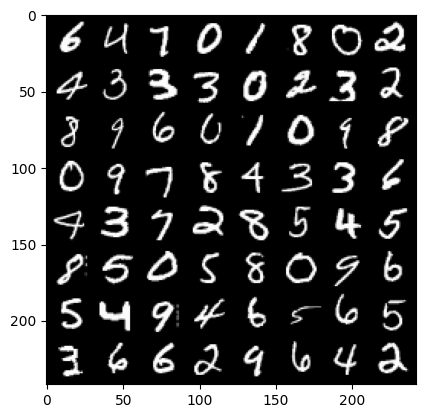

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1,2,0)))


data_iter = iter(trainloader)
images, labels = next(data_iter)

imshow(torchvision.utils.make_grid(images))

In [4]:
# parameters
N_STEPS = 28
N_INPUTS = 28
N_NEURONS = 150
N_OUTPUTS = 10
N_EPHOCS = 10

In [12]:
import torch.nn as nn
class ImageRNN(nn.Module):
  def __init__(self, batch_size, n_steps, n_inputs, n_neurons, n_outputs):
    super(ImageRNN, self). __init__()

    self.n_neurons = n_neurons
    self.batch_size = batch_size
    self.n_steps = n_steps
    self.n_inputs = n_inputs
    self.n_outputs = n_outputs

    self.basic_rnn = nn.RNN(self.n_inputs, self.n_neurons)


    self.FC = nn.Linear(self.n_neurons, self.n_outputs)


  def init_hidden(self,):
    return(torch.zeros(1, self.batch_size, self.n_neurons))

  def forward(self,X):
    X=X.permute(1,0,2)
    self.batch_size= X.size(1)
    self.hidden = self.init_hidden()

    lstm_out, self.hidden = self.basic_rnn(X, self.hidden)
    out = self.FC(self.hidden)

    return out.view(-1, self.n_outputs)

In [13]:
dataiter = iter(trainloader)
image, labels = next(dataiter)
model = ImageRNN(BATCH_SIZE, N_STEPS, N_INPUTS, N_NEURONS, N_OUTPUTS)
logits = model(image.view(-1,28,28))
print(logits[0:10])

tensor([[-0.1096, -0.1047, -0.0249, -0.0613, -0.0278, -0.0306, -0.1388, -0.0859,
         -0.0245, -0.0247],
        [-0.1092, -0.1058, -0.0232, -0.0639, -0.0220, -0.0217, -0.1343, -0.0838,
         -0.0281, -0.0235],
        [-0.1155, -0.1001, -0.0234, -0.0565, -0.0310, -0.0290, -0.1362, -0.0853,
         -0.0382, -0.0238],
        [-0.1091, -0.1112, -0.0205, -0.0684, -0.0212, -0.0220, -0.1265, -0.0854,
         -0.0204, -0.0251],
        [-0.1059, -0.1071, -0.0236, -0.0672, -0.0213, -0.0247, -0.1315, -0.0858,
         -0.0253, -0.0239],
        [-0.1163, -0.1068, -0.0226, -0.0688, -0.0245, -0.0184, -0.1350, -0.0813,
         -0.0233, -0.0318],
        [-0.1122, -0.1216,  0.0140, -0.0588, -0.0285, -0.0111, -0.1307, -0.1012,
         -0.0250, -0.0367],
        [-0.1009, -0.1036, -0.0293, -0.0613, -0.0222, -0.0292, -0.1448, -0.0809,
         -0.0252, -0.0243],
        [-0.1112, -0.1086, -0.0223, -0.0693, -0.0167, -0.0236, -0.1399, -0.0798,
         -0.0251, -0.0144],
        [-0.1164, -

In [15]:
import torch.optim as optim

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = ImageRNN(BATCH_SIZE, N_STEPS, N_INPUTS, N_NEURONS, N_OUTPUTS)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)
def get_accuracy(logit, target, batch_size):
  '''Obtain accuracy for training round'''

  corrects = (torch.max(logit,1)[1].view(target.size()).data == target.data).sum()
  accuracy = 100.0 * corrects/batch_size
  return accuracy.item()

In [17]:
for epoch in range(N_EPHOCS):
  train_running_loss = 0.0
  train_acc = 0.0
  model.train()

  for i, data in enumerate(trainloader):
    optimizer.zero_grad()

    model.hidden = model.init_hidden()

    inputs, labels = data
    inputs = inputs.view(-1,28,28)

    outputs = model(inputs)

    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    train_running_loss += loss.detach().item()
    train_acc += get_accuracy(outputs, labels, BATCH_SIZE)

  model.eval()
  print('For Epoch:%d || Loss = %.4f || Train Accuracy := %.2f '
        %(epoch, train_running_loss / i, train_acc/i))

For Epoch:0 || Loss = 0.2980 || Train Accuracy := 91.44 
For Epoch:1 || Loss = 0.2280 || Train Accuracy := 93.50 
For Epoch:2 || Loss = 0.1932 || Train Accuracy := 94.55 
For Epoch:3 || Loss = 0.1693 || Train Accuracy := 95.24 
For Epoch:4 || Loss = 0.1553 || Train Accuracy := 95.65 
For Epoch:5 || Loss = 0.1448 || Train Accuracy := 96.03 
For Epoch:6 || Loss = 0.1288 || Train Accuracy := 96.42 
For Epoch:7 || Loss = 0.1192 || Train Accuracy := 96.77 
For Epoch:8 || Loss = 0.1210 || Train Accuracy := 96.64 
For Epoch:9 || Loss = 0.1152 || Train Accuracy := 96.83 


In [18]:
test_acc = 0.0
for i, data in enumerate(testloader, 0):
    inputs, labels = data
    inputs = inputs.view(-1, 28, 28)

    outputs = model(inputs)

    test_acc += get_accuracy(outputs, labels, BATCH_SIZE)

print('Test Accuracy: %.2f'%( test_acc/i))

Test Accuracy: 95.75
